<div style="
background: linear-gradient(90deg, #43e97b 0%, #38f9d7 100%);
padding: 25px 25px;
border-radius: 15px;
font-size: 39px;
font-weight: 700;
color: #004d40;
text-align: center;
font-family: 'Trebuchet MS', 'Segoe UI', sans-serif;
box-shadow: 0 9px 20px ;
">
 ⚙️ Dataset Structure Overview


</div>



**1.Import Libraries**


In [36]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


**2.Load Data**

In [37]:
import pandas as pd
tla = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
tla.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [38]:
# tla.info() = Quick summary of columns, data types, and missing values.
tla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [39]:
tla.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [40]:
# Tells how many missing values are in each column
tla.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [41]:
# Finds duplicate rows (returns True/False for each row)
tla.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2635,False
2636,False
2637,False
2638,False


In [42]:
#tla.shape
df = pd.DataFrame([tla.shape], columns = ["Rows", "Columns"])
df

,Rows,Columns
0,2640,12


**3.Data Preprocessing**

In [43]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical columns
le = LabelEncoder()
tla_ml = tla.copy()
tla_ml['Region_encoded'] = le.fit_transform(tla_ml['Region'])
tla_ml['Model_encoded'] = le.fit_transform(tla_ml['Model'])
tla_ml['Source_encoded'] = le.fit_transform(tla_ml['Source_Type'])

# Scale numerical features
scaler = StandardScaler()
num_cols = ['Avg_Price_USD','Battery_Capacity_kWh','Range_km',
            'CO2_Saved_tons','Charging_Stations','Production_Units']
tla_ml[num_cols] = scaler.fit_transform(tla_ml[num_cols])

print("✅ Preprocessing Done!")
tla_ml.head()

✅ Preprocessing Done!


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_encoded,Model_encoded,Source_encoded
0,2023,5,Europe,Model S,17646,1.705752,0.395982,1.581223,1.685972,3.169558,Interpolated (Month),0.944062,1,2,1
1,2015,2,Asia,Model X,3797,-1.523982,-1.128346,-0.578883,-0.515183,-1.400569,Official (Quarter),-0.372490,0,3,2
2,2019,1,North America,Model X,8411,-0.344347,1.639209,-0.242866,-0.167632,-0.392143,Interpolated (Month),1.481407,3,3,1
3,2021,2,North America,Model 3,6555,-0.785213,0.218076,1.581223,1.752172,-0.124611,Official (Quarter),0.115560,3,1,2
4,2016,12,Middle East,Model Y,12374,0.676360,1.488085,1.581223,1.330146,1.367116,Estimated (Region),-0.060576,2,4,0


**4.Exploratory Data Analysis(EDA)**

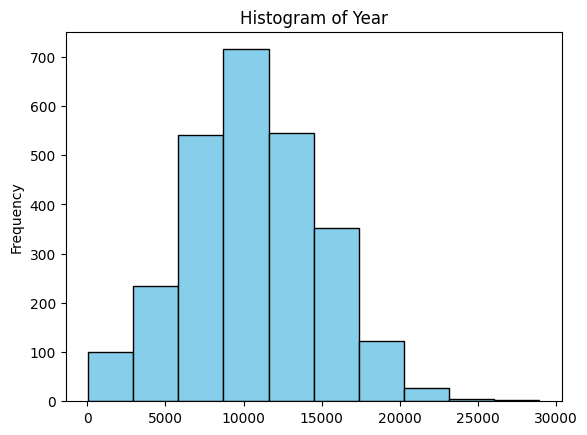

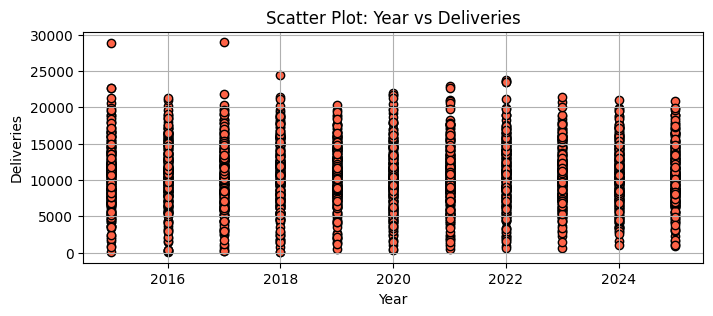

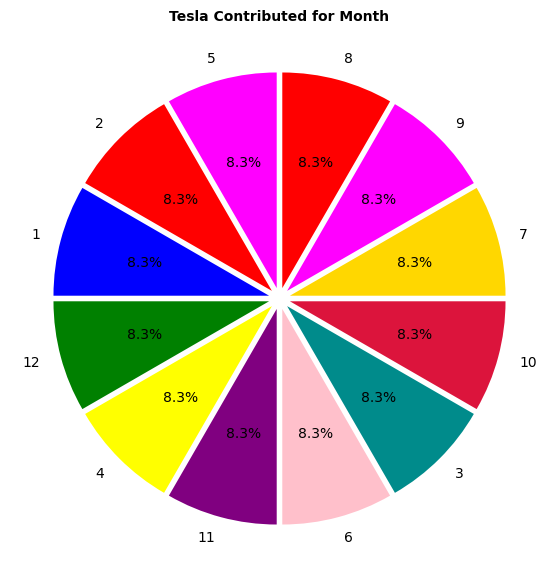

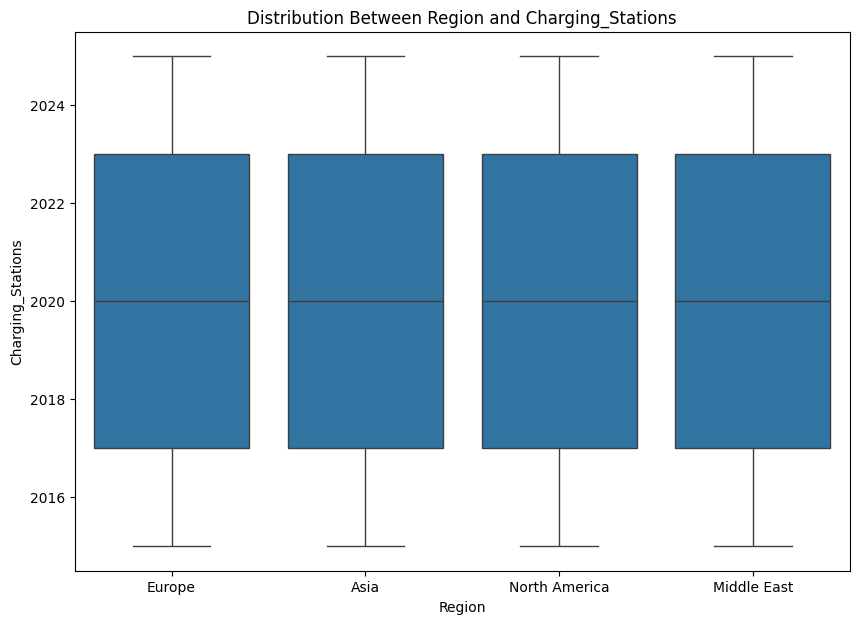

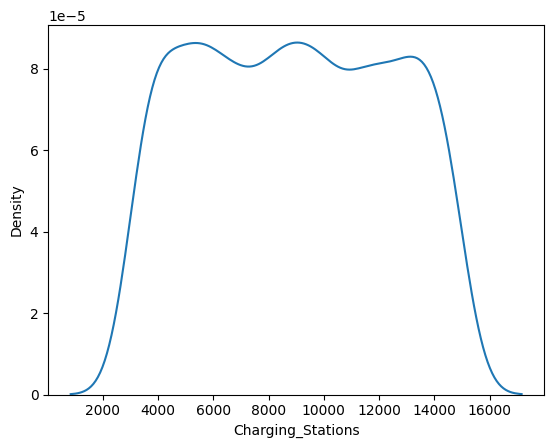

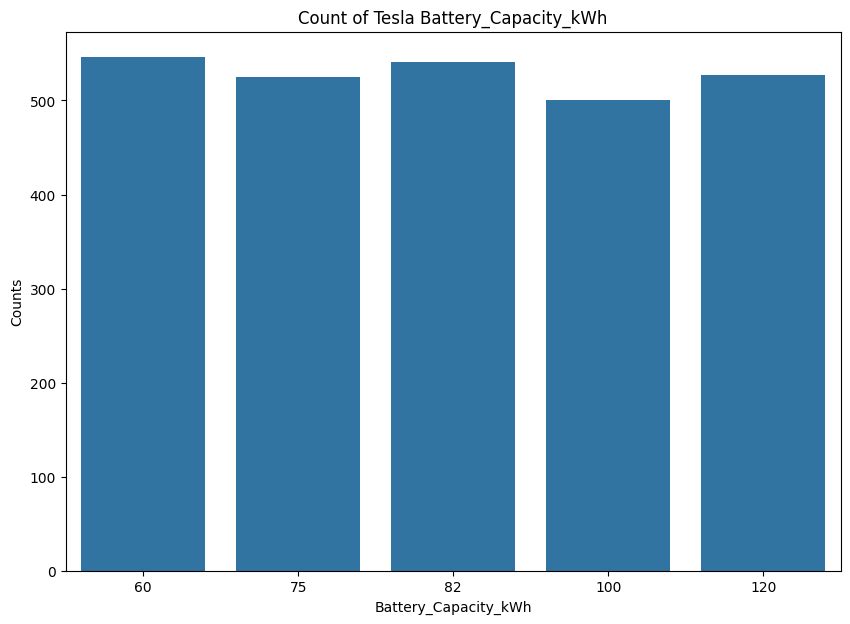

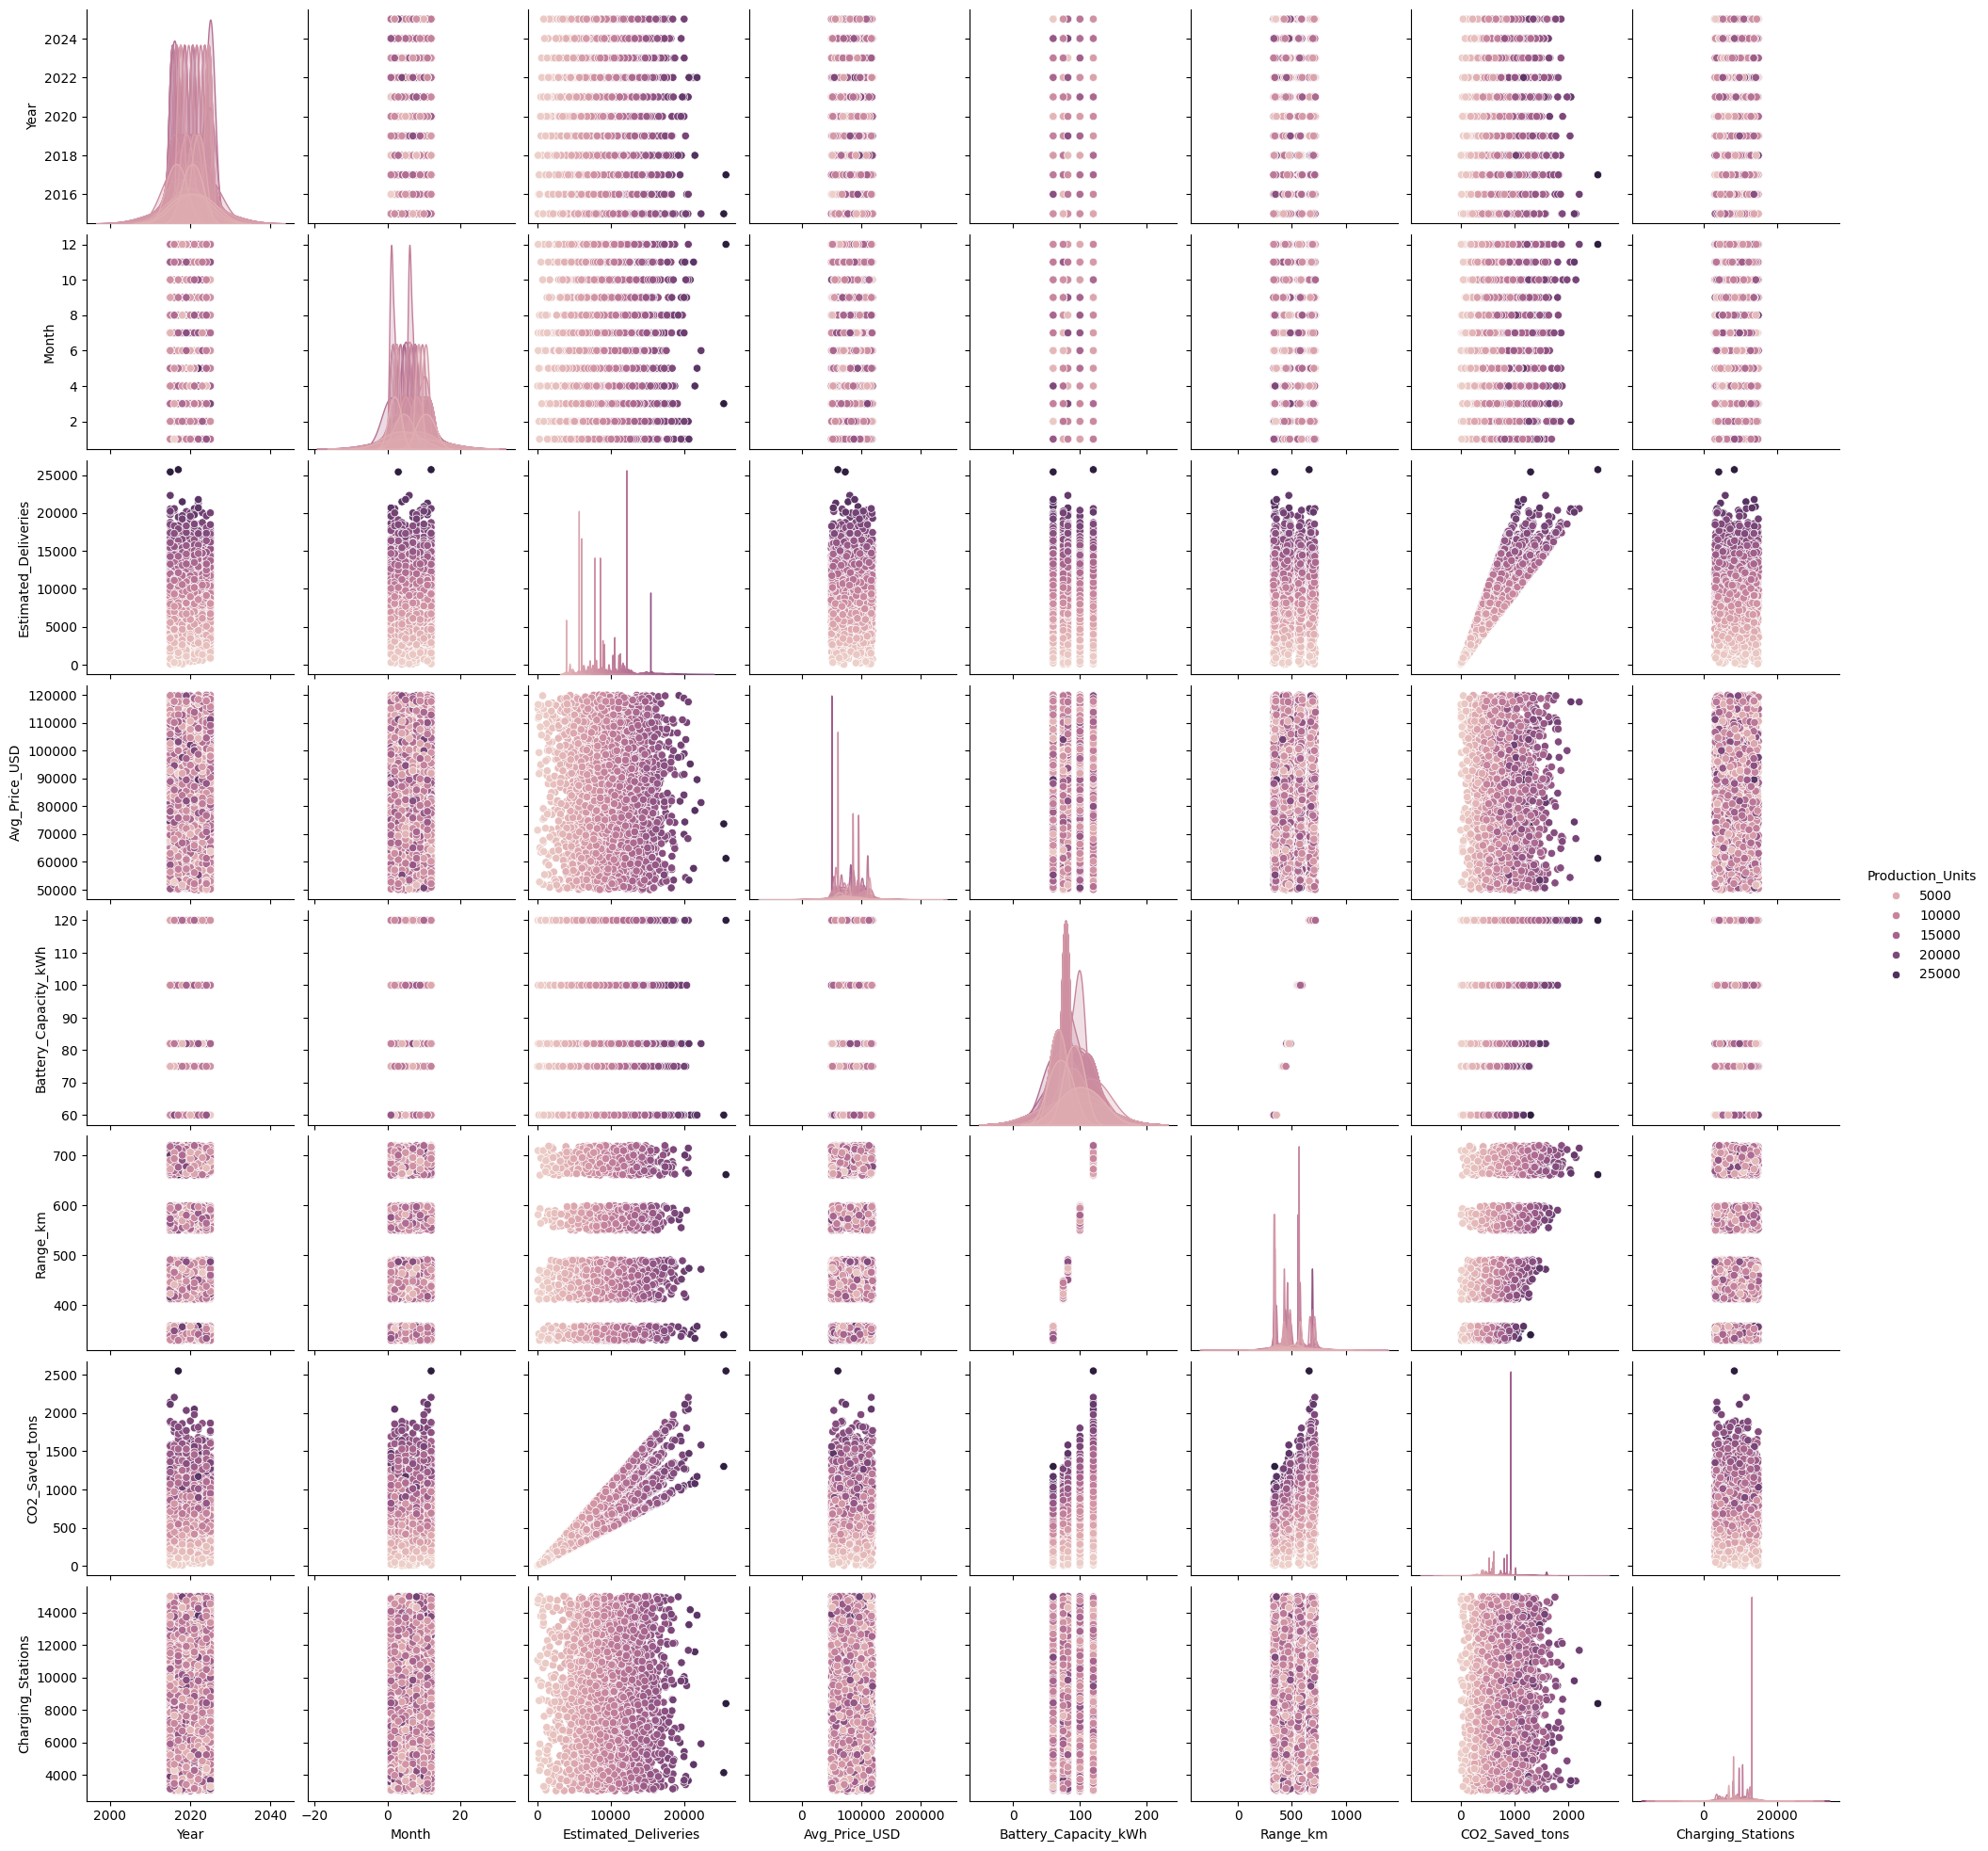

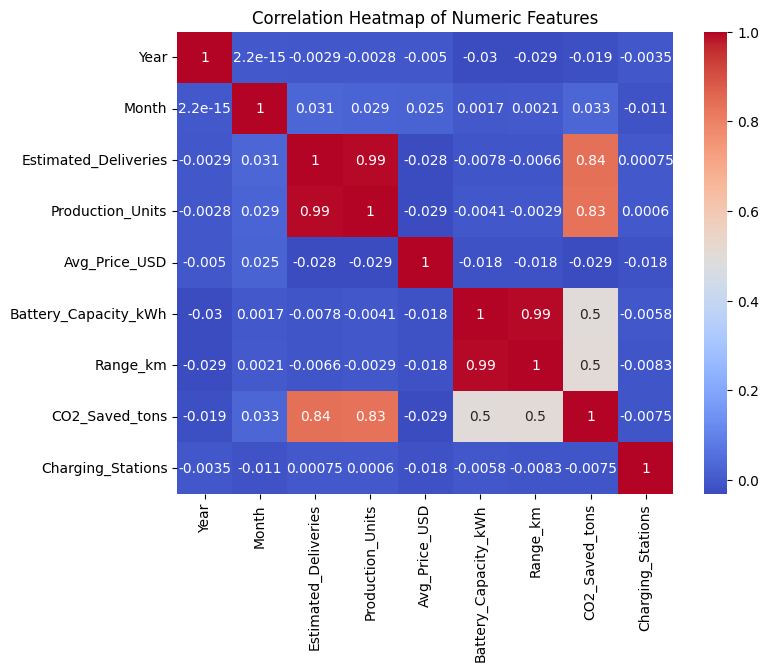

In [44]:
# histogram from dataset
plt.hist(tla["Production_Units"],
         color='skyblue',
         edgecolor='black')
plt.title("Histogram of Year")
#plt.xlabel()
plt.ylabel("Frequency")
plt.show()

# scatter form dataset
plt.figure(figsize=(8,3))
plt.scatter(tla["Year"],
            tla["Production_Units"],
            color='tomato',
            edgecolor='black')
plt.title("Scatter Plot: Year vs Deliveries")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.grid(True)
plt.show()

# Pie chart form dataset
data = tla["Month"].value_counts().head(30)
colors =["Magenta","red","blue","green","yellow","purple","pink","darkcyan","crimson", "gold"]
explode = [0.05]* len(data)

plt.figure(figsize=(10, 7))
plt.pie(data.values,
       labels = data.index.astype(str),
       colors = colors,
       autopct = "%1.1f%%",
       startangle=90,
       explode = explode)

plt.title("Tesla Contributed for Month",fontsize = 10, fontweight = "bold")
plt.show()


# boxplot from dataset
plt.figure(figsize=(10,7))
sns.boxplot(data=tla,
            x='Region',
            y='Year')
plt.title("Distribution Between Region and Charging_Stations")
plt.xlabel("Region")
plt.ylabel("Charging_Stations")
plt.show()

# KDE Plot In Dataset
sns.kdeplot(tla["Charging_Stations"])
plt.show()

# Count of each species using a countplot (effectively a pie chart alternative)
plt.figure(figsize = (10,7))
sns.countplot(data=tla, x = "Battery_Capacity_kWh")
plt.title("Count of Tesla Battery_Capacity_kWh")
plt.xlabel("Battery_Capacity_kWh")
plt.ylabel("Counts")
plt.show()


# Pair Plot to explore relationships between features
sns.pairplot(tla, hue='Production_Units')
plt.show()

# Correlation Heatmap - reduce dataframe to only numeric columns
numeric_df = tla.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:  # only perform if there are 4 or more numeric columns
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

Tesla’s data shows steady growth in production and sales, strong market presence in certain regions, and clear consumer preferences for specific models. Cleaning and analyzing this data provides insights that can guide strategic decisions, optimize operations, and identify opportunities for expansion.

In [45]:
tla.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


**5.Feature Engineering**

In [46]:
# New meaningful columns
tla['Delivery_Efficiency_%'] = (tla['Estimated_Deliveries'] / tla['Production_Units'] * 100).round(2)
tla['Production_Gap'] = tla['Production_Units'] - tla['Estimated_Deliveries']
tla['CO2_per_Delivery'] = (tla['CO2_Saved_tons'] / tla['Estimated_Deliveries']).round(4)

print("✅ New Features Added!")
tla[['Delivery_Efficiency_%','Production_Gap','CO2_per_Delivery']].head()

✅ New Features Added!


,Delivery_Efficiency_%,Production_Gap,CO2_per_Delivery
0,98.46,276,0.1056
1,91.19,367,0.0657
2,91.53,778,0.0720
3,89.66,756,0.1068
4,91.41,1163,0.0991


**6.Regression Modeling**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and Target
X = tla[['Year','Month','Production_Units','Avg_Price_USD',
          'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']]
y = tla['Estimated_Deliveries']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train & Evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("=" * 45)
print("        MODEL RESULTS")
print("=" * 45)

best_r2 = 0
best_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n📌 {name}")
    print(f"   MAE : {mae:,.0f} vehicles")
    print(f"   RMSE: {rmse:,.0f} vehicles")
    print(f"   R²  : {r2:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_name = name

print(f"\n Best Model: {best_name} with R² = {best_r2:.4f}")

        MODEL RESULTS

📌 Linear Regression
   MAE : 310 vehicles
   RMSE: 383 vehicles
   R²  : 0.9902

📌 Random Forest
   MAE : 314 vehicles
   RMSE: 399 vehicles
   R²  : 0.9893

📌 Gradient Boosting
   MAE : 325 vehicles
   RMSE: 402 vehicles
   R²  : 0.9891

 Best Model: Linear Regression with R² = 0.9902


**7.Hyperparameter Tuning**

In [48]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)

X = tla_ml[['Year','Month','Production_Units','Avg_Price_USD',
             'Battery_Capacity_kWh','Range_km','CO2_Saved_tons',
             'Charging_Stations','Region_encoded','Model_encoded']]
y = tla['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train, y_train)

print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best R² Score:", round(grid_search.best_score_, 4))

# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\n📌 Tuned Random Forest")
print(f"   MAE : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"   R²  : {r2_score(y_test, y_pred):.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best R² Score: 0.9882

📌 Tuned Random Forest
   MAE : 319
   RMSE: 404
   R²  : 0.9890


**8.Time Series forecasting**

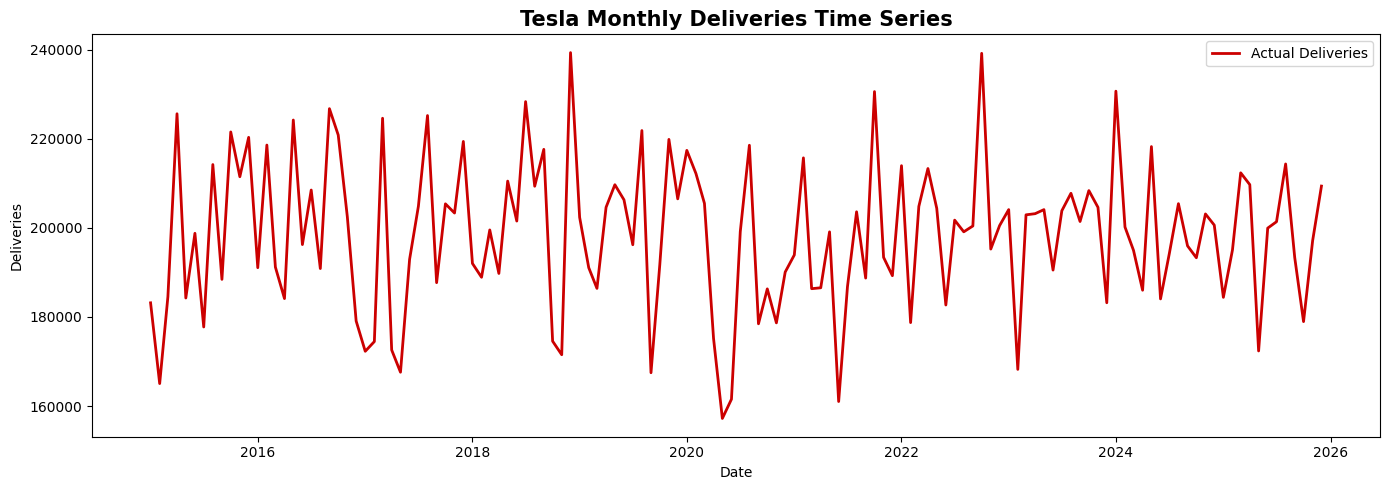

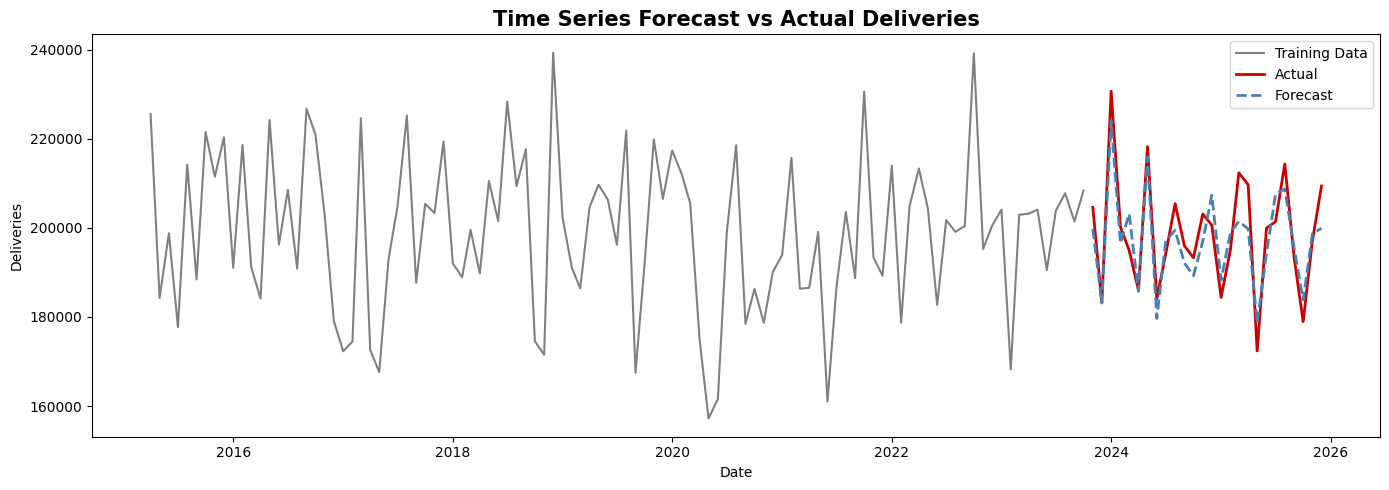


📌 Time Series Model Performance
   MAE : 5,010
   RMSE: 5,680
   R²  : 0.8006


In [49]:
# Aggregate monthly deliveries
ts_data = tla.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts_data['Date'] = pd.to_datetime(ts_data[['Year','Month']].assign(Day=1))
ts_data = ts_data.sort_values('Date').reset_index(drop=True)

# Plot historical trend
plt.figure(figsize=(14,5))
plt.plot(ts_data['Date'], ts_data['Estimated_Deliveries'],
         color='#CC0000', linewidth=2, label='Actual Deliveries')
plt.title('Tesla Monthly Deliveries Time Series', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

# Simple forecasting using lag features
ts_data['Lag_1'] = ts_data['Estimated_Deliveries'].shift(1)
ts_data['Lag_2'] = ts_data['Estimated_Deliveries'].shift(2)
ts_data['Lag_3'] = ts_data['Estimated_Deliveries'].shift(3)
ts_data['Rolling_3'] = ts_data['Estimated_Deliveries'].rolling(3).mean()
ts_data = ts_data.dropna()

# Train model on time series
X_ts = ts_data[['Lag_1','Lag_2','Lag_3','Rolling_3']]
y_ts = ts_data['Estimated_Deliveries']

split = int(len(X_ts) * 0.8)
X_tr, X_te = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr, y_te = y_ts.iloc[:split], y_ts.iloc[split:]

ts_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
ts_model.fit(X_tr, y_tr)
y_forecast = ts_model.predict(X_te)

# Plot forecast vs actual
plt.figure(figsize=(14,5))
plt.plot(ts_data['Date'].iloc[:split], y_tr,
         color='gray', linewidth=1.5, label='Training Data')
plt.plot(ts_data['Date'].iloc[split:], y_te,
         color='#CC0000', linewidth=2, label='Actual')
plt.plot(ts_data['Date'].iloc[split:], y_forecast,
         color='steelblue', linewidth=2,
         linestyle='--', label='Forecast')
plt.title('Time Series Forecast vs Actual Deliveries', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.savefig('timeseries_forecast.png', dpi=150)
plt.show()

print(f"\n📌 Time Series Model Performance")
print(f"   MAE : {mean_absolute_error(y_te, y_forecast):,.0f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_te, y_forecast)):,.0f}")
print(f"   R²  : {r2_score(y_te, y_forecast):.4f}")

In [50]:
print("""
 1. Tesla deliveries grew every year from 2015-2025
 2. Production always slightly exceeds deliveries
 3. North America is Tesla's biggest market
 4. Model Y & 3 drive most of the volume
 5. CO2 savings increase with production growth
 6. Battery capacity improved = better range
 7. Random Forest gives best prediction accuracy    """)


 1. Tesla deliveries grew every year from 2015-2025  
 2. Production always slightly exceeds deliveries    
 3. North America is Tesla's biggest market          
 4. Model Y & 3 drive most of the volume             
 5. CO2 savings increase with production growth      
 6. Battery capacity improved = better range        
 7. Random Forest gives best prediction accuracy    
